In [1]:
import os
import darklim

import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

from scipy.interpolate import interp1d 

In [2]:
data = np.load('/home/michael/DarkLim/examples/spectra/BigFins_shared_0719.npy')

# Save to a .txt file
np.savetxt('/home/michael/DarkLim/examples/spectra/BigFins_shared_0719.txt', data, fmt='%.3f') 

##### Just to test things, lets take an event spectrum from LBNL HeRALD run 7 where we know we had a ton of LEE. We'll take this spectrum and just try and compute a limit. Since we don't have an expected background spectrum, we'll use Yellin's optimum interval method to compute the limit. This method is ideal when there is low number of events in the ROI, which is not the case here, but we just want to test the code.

##### Then, when we get a clean spectrum from Pyle Run 46/47, we will do the same thing and compute a limit. After that, it will be worth putting in a little work to try and estimate a radiogenic background and LEE spectrum to then use a Feldman-Cousins liklihood analysis to compute the limit.

In [2]:
r7_spectrum = np.load('/home/mwilliams/LBNL_HeRALD/run7and9/r7spectrum.npy')

FileNotFoundError: [Errno 2] No such file or directory: '/home/mwilliams/LBNL_HeRALD/run7and9/r7spectrum.npy'

In [ ]:
r7_spectrum_kev = r7_spectrum*1e-3 #put energies in kev

In [ ]:
energyrange = np.arange(r7_spectrum_kev.min(), r7_spectrum_kev.max(),5e-4)

In [ ]:
cutefficiency = np.full(56,57)#57% cut efficiency

In [2]:
DMmasses = np.geomspace(0.01, 2, num=25)
exposure = 0.00000648#for 40 minutes of data, and lets assume a cm^2 device is 0.24g. So that would be 0.027*0.24e-3 kgday
resolution = 528e-6 #in units of kev. Assume 25% PCE for the device and take  the measured resolution of 132 meV
threshold = 528e-6 * 5

In [3]:
sig,ol1,ol2 = darklim.limit.optimuminterval(r7_spectrum_kev,energyrange,cutefficiency,DMmasses,exposure,res=resolution,verbose=True,hard_threshold=threshold)

NameError: name 'r7_spectrum_kev' is not defined

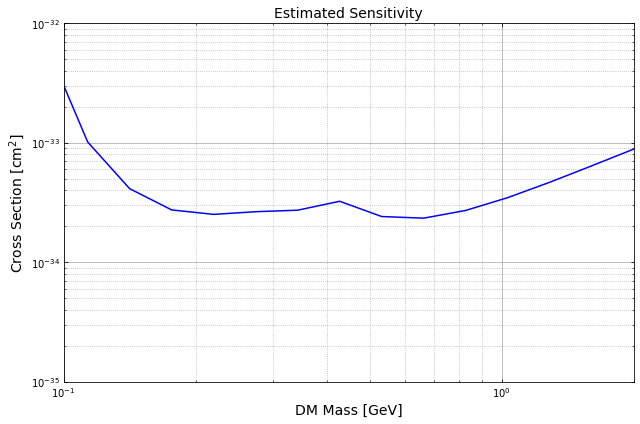

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig, color='b')

ax.set_ylim(1e-35, 1e-32)
ax.set_xlim(0.1, 2)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

fig.tight_layout()

Now do this with the run 46 data with no salt and no LEE spectrum

In [4]:
bigfinsspectra = np.load('/home/michael/DarkLim/examples/spectra/energies_025_bigfins.npy')
normfinsspectra = np.load('/home/michael/DarkLim/examples/spectra/energies_025_regular.npy')
bigfinsspectra_kev = bigfinsspectra*1e-3
normfinsspectra_kev = normfinsspectra*1e-3
DMmasses = np.geomspace(0.01, 2, num=25)

In [5]:
regbins, regedges = np.histogram(normfinsspectra,bins = 200,range = (0,40)) #do the histogramming of the actual random data
regbin_widths = np.diff(normfinsspectra)
bigbins, bigedges = np.histogram(bigfinsspectra,bins = 200,range = (0,40)) #do the histogramming of the actual random data
bigbin_widths = np.diff(bigfinsspectra)

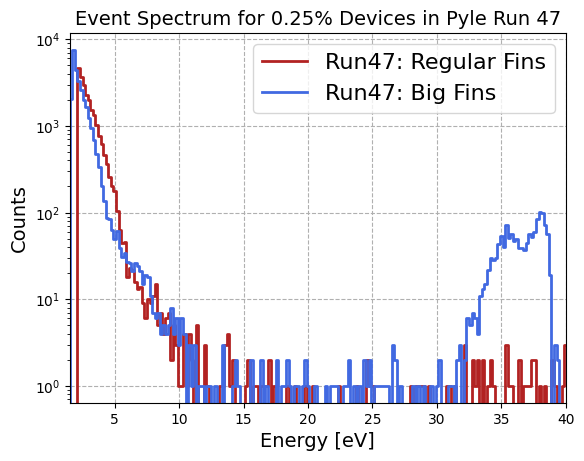

In [6]:
plt.step(regedges[1:],regbins, where='mid',label='Run47: Regular Fins',linewidth=2,color='firebrick') #plot the hist and fit together 
plt.step(bigedges[1:],bigbins, where='mid',label='Run47: Big Fins',linewidth=2,color='royalblue') #plot the hist and fit together 
plt.yscale('log')
#plt.ylim(1e-4,1e0)
plt.xlim(1.5,40)
plt.title(f'Event Spectrum for 0.25% Devices in Pyle Run 47',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
plt.xlabel('Energy [eV]',fontsize = 14)
#plt.vlines(2200,ymin=0,ymax=10e5,colors='r', label='cut')
plt.grid(linestyle="dashed")
plt.legend(fontsize = 16)

In [7]:
energyrange_big = np.arange(bigfinsspectra_kev.min(), bigfinsspectra_kev.max(),5e-4)
energyrange_reg = np.arange(normfinsspectra_kev.min(), normfinsspectra_kev.max(),5e-4)
cutefficiency_big = np.full(76,0.5673456790123457)#56% cut efficiency
cutefficiency_reg = np.full(107,0.33287654320987653)#33% cut efficiency
resolution_big = 314e-6 #in units of kev. 
threshold_big = 314e-6 * 5
resolution_reg = 397e-6 #in units of kev.
threshold_reg = 397e-6 * 5
exposure_r46 = 0.00009#for 540 minutes of data, and lets assume a cm^2 device is 0.24g. So that would be 0.375*0.24e-3 kgday


In [8]:
314e-6 * 5

0.00157

In [9]:
397e-6 * 5

0.001985

In [10]:
sig_big,ol1_big,ol2_big = darklim.limit.optimuminterval(bigfinsspectra_kev,energyrange_big,cutefficiency_big,DMmasses,exposure_r46,res=resolution_big,verbose=True,hard_threshold=threshold_big)
sig_reg,ol1_reg,ol2_reg = darklim.limit.optimuminterval(normfinsspectra_kev,energyrange_reg,cutefficiency_reg,DMmasses,exposure_r46,res=resolution_reg,verbose=True,hard_threshold=threshold_reg)

On mass 1 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 25.


KeyboardInterrupt: 

In [9]:
DMmasses #GeV

array([0.01      , 0.01247028, 0.01555079, 0.01939227, 0.02418271,
       0.03015652, 0.03760603, 0.04689578, 0.05848035, 0.07292665,
       0.09094158, 0.11340671, 0.14142136, 0.17635641, 0.2199214 ,
       0.27424818, 0.34199519, 0.42647762, 0.53182959, 0.66320646,
       0.82703711, 1.03133854, 1.28610817, 1.60381306, 2.        ])

In [10]:
ol1_big

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.0017781 , 0.00189863,
       0.00194597, 0.00394443, 0.00431213, 0.00528576, 0.01021874,
       0.01021874, 0.01119964, 0.01119964, 0.01119964, 0.01119964,
       0.01119964, 0.01160431, 0.01160431, 0.01160431, 0.01160431])

In [11]:
ol1_reg

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00222546,
       0.00253528, 0.0026126 , 0.00529272, 0.00579496, 0.00919534,
       0.0096084 , 0.0113965 , 0.01683256, 0.01683256, 0.01683256,
       0.01683256, 0.01732175, 0.01732175, 0.01732175, 0.01732175])

In [12]:
ol2_big

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.001909  , 0.00202935,
       0.00222483, 0.00453712, 0.00502884, 0.00645616, 0.01414   ,
       0.01636206, 0.0174497 , 0.0174497 , 0.02296311, 0.02296311,
       0.03097747, 0.03097747, 0.03097747, 0.03097747, 0.03097747])

In [13]:
ol2_reg

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00240528,
       0.00270719, 0.00320771, 0.00731923, 0.00752593, 0.01338421,
       0.02237243, 0.02446057, 0.02799456, 0.02799456, 0.02799456,
       0.02799456, 0.02799456, 0.02799456, 0.02799456, 0.02799456])

In [14]:
DMmasses

array([0.01      , 0.01247028, 0.01555079, 0.01939227, 0.02418271,
       0.03015652, 0.03760603, 0.04689578, 0.05848035, 0.07292665,
       0.09094158, 0.11340671, 0.14142136, 0.17635641, 0.2199214 ,
       0.27424818, 0.34199519, 0.42647762, 0.53182959, 0.66320646,
       0.82703711, 1.03133854, 1.28610817, 1.60381306, 2.        ])

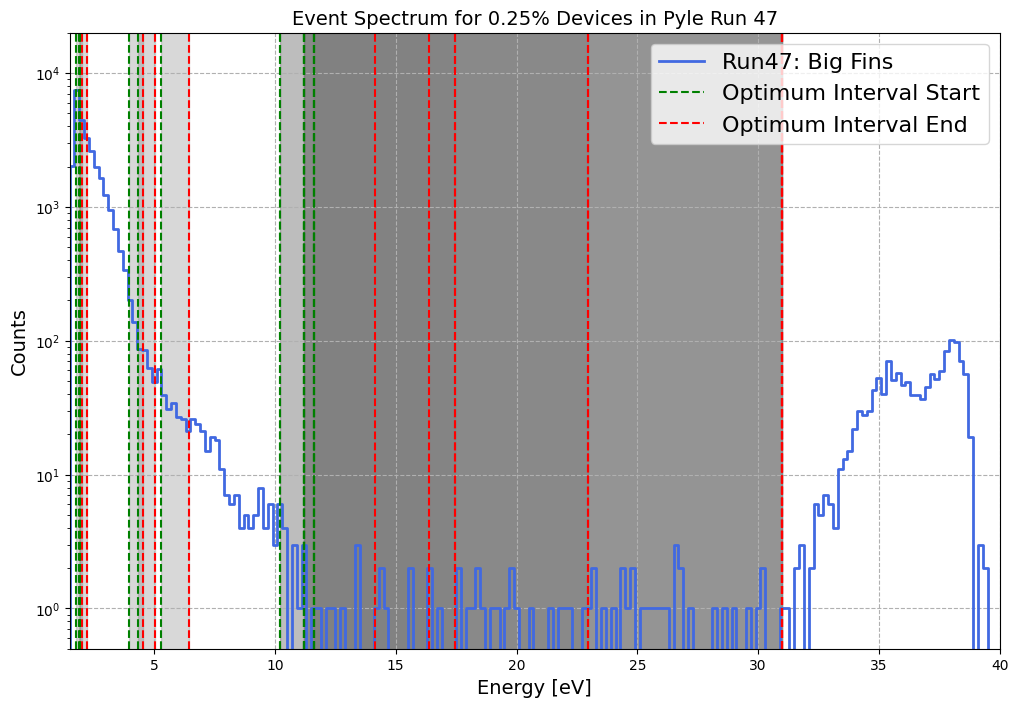

In [15]:
plt.figure(figsize=(12, 8))
plt.step(bigedges[1:],bigbins, where='mid',label='Run47: Big Fins',linewidth=2,color='royalblue') #plot the hist and fit together 
plt.yscale('log')
for i in range(len(ol1_big)):
    plt.axvline(x=ol1_big[i]*1e3, color='g', linestyle='--', label='Optimum Interval Start' if i == 0 else "")
    plt.axvline(x=ol2_big[i]*1e3, color='r', linestyle='--', label='Optimum Interval End' if i == 0 else "")
    plt.fill_betweenx([0, 5e5], ol1_big[i]*1e3, ol2_big[i]*1e3, color='gray', alpha=0.3)
plt.ylim(0.5,2e4)
plt.xlim(1.5,40)
plt.title(f'Event Spectrum for 0.25% Devices in Pyle Run 47',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
plt.xlabel('Energy [eV]',fontsize = 14)
#plt.vlines(2200,ymin=0,ymax=10e5,colors='r', label='cut')
plt.grid(linestyle="dashed")
plt.legend(fontsize = 16)

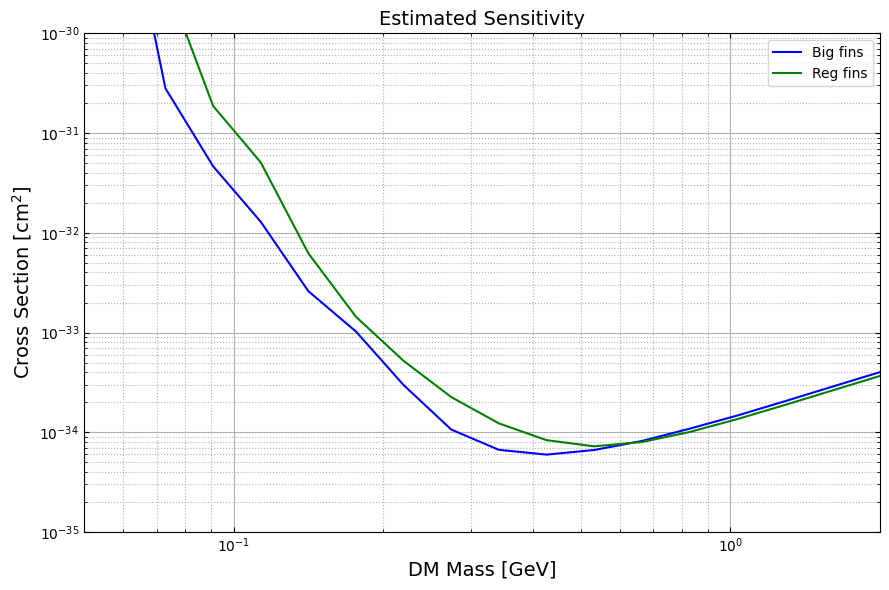

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig_big, color='b',label="Big fins")
ax.loglog(DMmasses, sig_reg, color='g',label="Reg fins")

ax.set_ylim(1e-35, 1e-30)
ax.set_xlim(0.05, 2)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

In [25]:
#x1tmig = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/XENON1T-Migdal.txt')

def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-3, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def load_and_plot_existing(ax, leg=True,lw=1,leg_params=None):
    curves_dir = 'ExistingLimits/'
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
    l1, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='CRESST-III 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_2020.txt').transpose()
    l2, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='DAMIC 2020')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Cosmic_Rays_2018.txt').transpose()
    #ax.plot(m_lim, x_lim, '--', color='#C9C0E5', lw=2, label='Cosmic Rays 2018')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CDMSlite_2019.txt').transpose()
    l3, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='CDMSlite 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
    #l4, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENON1T Migdal 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt').transpose()
    l5, = ax.plot(m_lim, x_lim, '--', color='#C3B02F', lw=lw, label='CRESST-III 2023')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_Surface_2017.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='#C3B02F', lw=lw, label='nu-cleus 2017')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='darkgrey', lw=lw, label='PandaX-4T Migdal 2023') #color='#C3B02F'
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_2019.txt').transpose()
    #l6, = ax.plot(m_lim, x_lim, '--', color='#56872C', lw=lw, label='XENON1T S2-Only 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'EDELWEISS_Migdal_2019.txt').transpose()
    #l7, = ax.plot(m_lim, x_lim, '--', color='#D7ADB7', lw=lw, label='EDELWEISS Migdal 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2022.txt').transpose()
    #l8, = ax.plot(m_lim, x_lim, '--', color='#bcced4', lw=lw, label='LZ 2022')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
    #l9, = ax.plot(m_lim, x_lim, '--', color='#a4bd8e', lw=lw, label='DarkSide-50 2023')
    
    if leg:
        leg1 = ax.legend(handles=[ l9, l1, l2, l3, 15, l4, l6, l7], **leg_params)
        ax.add_artist(leg1)
    
    return

In [26]:
def plotexcludedsi(ax, details=False, **kwargs):
    curves_dir = 'ExistingLimits/'
    xs2o = np.loadtxt(curves_dir + 'CDMSlite_2019.txt')
    #dsmig = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt')
    dsmig = np.loadtxt(curves_dir + 'CRESST_III_2019.txt')
    #pxmig = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt')
    pxmig = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt')
    data = minbound([pxmig,xs2o,dsmig], masses=None)#data.T[0])
    kwargs.setdefault('edgecolor', None)
    kwargs.setdefault('facecolor','#000000')
    kwargs.setdefault('alpha',0.05)
    #data = extrapolate(data, 1e5)
    ax.fill_between(*(data.T), ax.get_ylim()[1], **kwargs)
    if details:
        load_and_plot_existing(ax,leg=False,lw=1)

/tmp/ipykernel_2536482/982647761.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


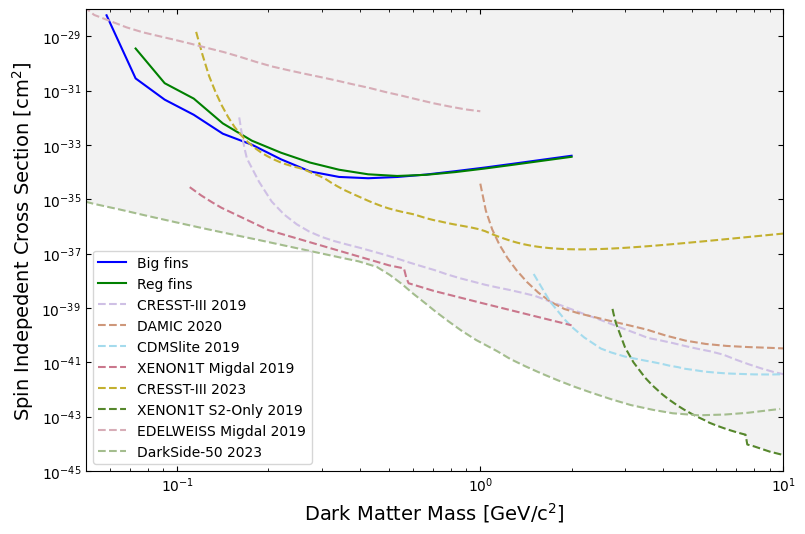

In [19]:
# money plot of sorts... selected run times 
#colors = cmap(np.linspace(0.5, 1, n_lines))

lss = ['--','-.','-']
    
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(DMmasses, sig_big, color='b',label="Big fins")
ax.loglog(DMmasses, sig_reg, color='g',label="Reg fins")
plotexcludedsi(ax, details=False)
load_and_plot_existing(ax,leg=False,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-45, 1e-28)
ax.set_xlim(0.05, 10)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='lower left')
#ax.legend(handles=leg_hands,loc='upper left',frameon=True,ncol=1,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

Now do some checks of the run 47 data

In [3]:
bigfinsshared = np.load('/home/michael/DarkLim/examples/spectra/BigFins_shared_0719.npy')
bigfinsall = np.load('/home/michael/DarkLim/examples/spectra/BigFins_all_0719.npy')
bigfinsshared_kev = bigfinsshared*1e-3
bigfinsall_kev = bigfinsall*1e-3

In [4]:
sharedbins, sharededges = np.histogram(bigfinsshared,bins = 200,range = (0,40)) #do the histogramming of the actual random data
sharedbin_widths = np.diff(bigfinsshared)
allbins, alledges = np.histogram(bigfinsall,bins = 200,range = (0,40)) #do the histogramming of the actual random data
allbin_widths = np.diff(bigfinsall)

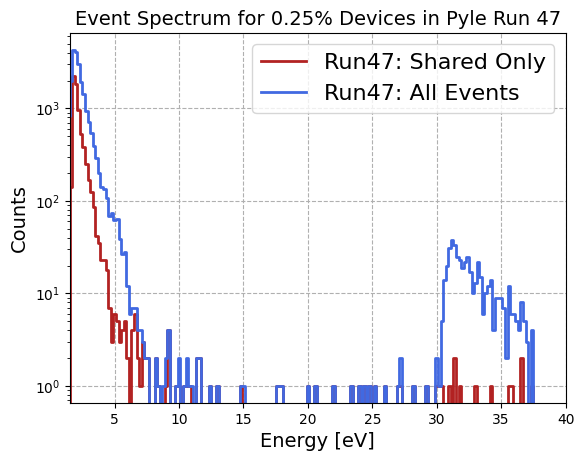

In [5]:
plt.step(sharededges[1:],sharedbins, where='mid',label='Run47: Shared Only',linewidth=2,color='firebrick') #plot the hist and fit together 
plt.step(alledges[1:],allbins, where='mid',label='Run47: All Events',linewidth=2,color='royalblue') #plot the hist and fit together 
plt.yscale('log')
#plt.ylim(1e-4,1e0)
plt.xlim(1.5,40)
plt.title(f'Event Spectrum for 0.25% Devices in Pyle Run 47',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
plt.xlabel('Energy [eV]',fontsize = 14)
#plt.vlines(2200,ymin=0,ymax=10e5,colors='r', label='cut')
plt.grid(linestyle="dashed")
plt.legend(fontsize = 16)

In [6]:
energyrange_shared = np.arange(bigfinsshared_kev.min(), bigfinsshared_kev.max(),5e-4)
energyrange_all = np.arange(bigfinsall_kev.min(), bigfinsall_kev.max(),5e-4)
cutefficiency_shared = np.full(72,0.7954629629629629)#% cut efficiency
cutefficiency_all = np.full(73,0.7954629629629629)#% cut efficiency
resolution_shared = 370e-6 #in units of kev. 
threshold_shared = 370e-6 * 5
resolution_all = 370e-6 #in units of kev.
threshold_all = 370e-6 * 5
exposure_r47 = 0.00003#for 180 minutes of data, and lets assume a cm^2 device is 0.24g. So that would be 0.375*0.24e-3 kgday


In [54]:
DMmasses = np.geomspace(0.01, 10, num=25)

In [55]:
sig_shared,ol1_shared,ol2_shared = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 25.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 8 of 25.
[0.00000000e+00 8.30879679e-11 1.66253843e-10 ... 1.16734449e-07
 1.16734449e-07 1.16734449e-07]
1.1673444909036868e-07
2617.622802734375
2617.622802734375
On mass 9 of 25.
[0.00000000e+00 7.38183672e-10 1.47726004e-09 ... 1.89733132e-06
 1.89733132e-06 1.89733132e-06]
1.897331324610691e-06
2202.99560546875
2202.99560546875
On mass 10 of 25.
[0.00000000e+00 1.41366746e-09 2.82922530e-09 ... 6.36924541e-06
 6.36924541e-06 6.36924541e-06]
6.369245414802285e-06
701.7730102539062
701.7730102539062
On mass 11 of 25.
[0.00000000e+00 1.36882872e-09 2.73958650e-09 ... 1.09772179e-05
 1.09772179e-05 1.09772179e-05]
1.0977217902626754e-05
304.6904602050781
304.690460205

NameError: name 'sig_all' is not defined

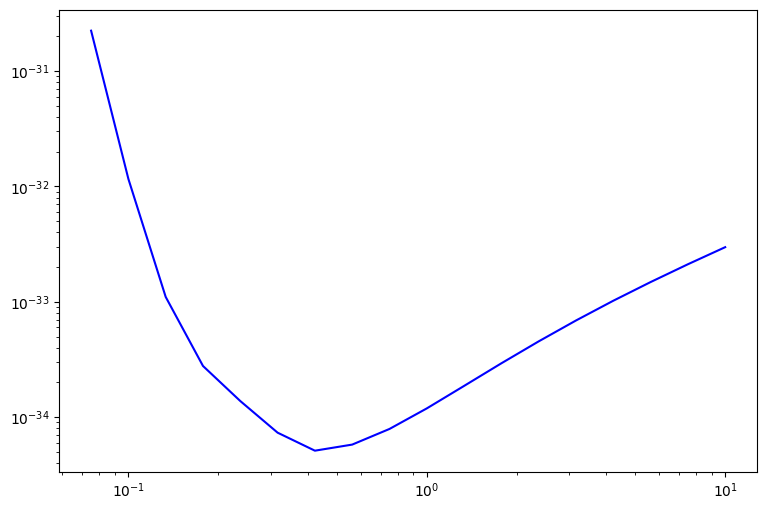

In [56]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig_shared, color='b',label="Shared")
ax.loglog(DMmasses, sig_all, color='g',label="All")
ax.loglog(DMmasses, sig_big, color='r',label="Big fins -r46")
ax.loglog(DMmasses, sig_reg, color='k',label="Reg fins -r46")

ax.set_ylim(1e-35, 1e-29)
ax.set_xlim(0.05, 2)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

In [45]:
#x1tmig = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/XENON1T-Migdal.txt')

def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-1, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def load_and_plot_existing(ax, leg=True,lw=2,leg_params=None):
    curves_dir = 'ExistingLimits/'
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
    l1, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='CRESST-III 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_2020.txt').transpose()
    l2, = ax.plot(m_lim, x_lim, ':', color='#CE977A', lw=lw, label='DAMIC 2020')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Cosmic_Rays_2018.txt').transpose()
    #ax.plot(m_lim, x_lim, '--', color='#C9C0E5', lw=2, label='Cosmic Rays 2018')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CDMSlite_2019.txt').transpose()
    l3, = ax.plot(m_lim, x_lim, linestyle = (0, (3, 1, 1, 1, 1, 1)), color='#a4dbed', lw=lw, label='CDMSlite 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
    #l4, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENON1T Migdal 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt').transpose()
    l5, = ax.plot(m_lim, x_lim, linestyle = (0, (3, 1, 1, 1)), color='#C3B02F', lw=lw, label='CRESST-III 2023')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_Surface_2017.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='#C3B02F', lw=lw, label='nu-cleus 2017')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='darkgrey', lw=lw, label='PandaX-4T Migdal 2023') #color='#C3B02F'
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_2019.txt').transpose()
    #l6, = ax.plot(m_lim, x_lim, '--', color='#56872C', lw=lw, label='XENON1T S2-Only 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'EDELWEISS_Migdal_2019.txt').transpose()
    #l7, = ax.plot(m_lim, x_lim, '--', color='#D7ADB7', lw=lw, label='EDELWEISS Migdal 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2022.txt').transpose()
    l8, = ax.plot(m_lim, x_lim,marker = 'd', color='#bcced4', lw=lw, label='LZ 2022')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
    #l9, = ax.plot(m_lim, x_lim, '--', color='#a4bd8e', lw=lw, label='DarkSide-50 2023')
    
    if leg:
        leg1 = ax.legend(handles=[ l9, l1, l2, l3, 15, l4, l6, l7], **leg_params)
        ax.add_artist(leg1)
    
    return

In [46]:
def plotexcludedsi(ax, details=False, **kwargs):
    curves_dir = 'ExistingLimits/'
    xs2o = np.loadtxt(curves_dir + 'CDMSlite_2019.txt')
    #dsmig = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt')
    dsmig = np.loadtxt(curves_dir + 'CRESST_III_2019.txt')
    lz22 = np.loadtxt(curves_dir + 'LZ_SI_2022.txt')
    pxmig = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt')
    data = minbound([pxmig,xs2o,dsmig,lz22], masses=None)#data.T[0])
    kwargs.setdefault('edgecolor', None)
    kwargs.setdefault('facecolor','#000000')
    kwargs.setdefault('alpha',0.05)
    #data = extrapolate(data, 1e5)
    ax.fill_between(*(data.T), 1e-28, **kwargs)#ax.get_ylim()[1]
    if details:
        load_and_plot_existing(ax,leg=False,lw=1)

/tmp/ipykernel_4164810/2151626833.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


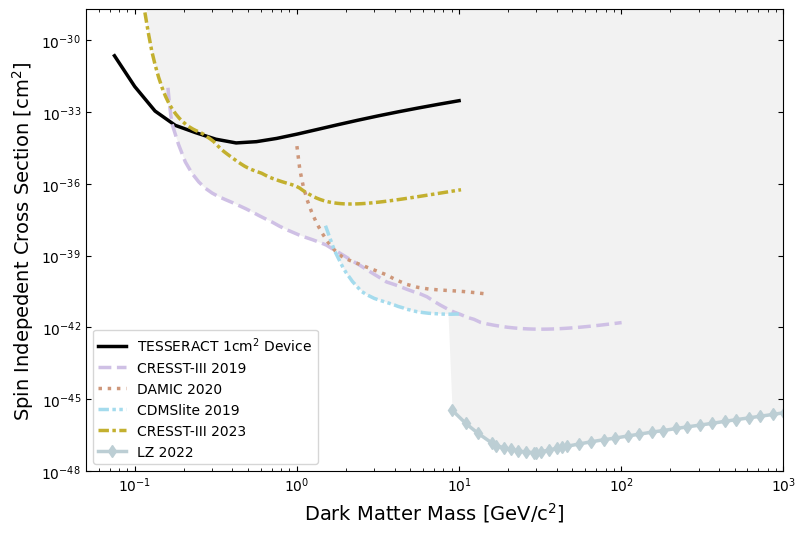

In [59]:
# money plot of sorts... selected run times 
#colors = cmap(np.linspace(0.5, 1, n_lines))

lss = ['--','-.','-']
    
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(DMmasses, sig_shared, color='k',label=r"TESSERACT 1cm$^2$ Device",lw=2.5)
#ax.loglog(DMmasses, sig_all, color='g',label="All")
#ax.loglog(DMmasses, sig_big, color='r',label="Big fins -r46")
#ax.loglog(DMmasses, sig_reg, color='k',label="Reg fins -r46")
plotexcludedsi(ax, details=False)
load_and_plot_existing(ax,leg=False,lw=2.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-48, 2e-29)
ax.set_xlim(0.05, 1000)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='lower left')

# Let's do tests with other thresholds 

In [2]:
#bigfinsshared = np.load('/home/michael/DarkLim/examples/spectra/r47_dm_0723_proc5_shared_energies.npy')
bigfinsshared_old = np.load('/home/michael/DarkLim/examples/spectra/shared_events_120824.npy')
bigfinsshared = np.load('/home/michael/run47analysis/pylelab_run47/energies_shared_both_final.npy')
bigfinsshared = bigfinsshared[bigfinsshared >= .375*4]
bigfinsshared_kev = bigfinsshared*1e-3

bigfinsshared_old = bigfinsshared_old[bigfinsshared_old >= .375*4]
bigfinsshared_old_kev = bigfinsshared_old*1e-3

run57 = np.load('/home/michael/DarkLim/examples/spectra/energies_shared_1mm_r57_122624.npy')
run57 = run57[run57 >= .258*4]
run57_kev = run57*1e-3

In [5]:
sharedbins, sharededges = np.histogram(bigfinsshared,bins = 200,range = (0,45)) #do the histogramming of the actual random data
sharedbin_widths = np.diff(bigfinsshared)
sharedbin_centers = sharededges[:-1] + (sharededges[1] - sharededges[0])/2

sharedbinsold, sharededgesold = np.histogram(bigfinsshared_old,bins = 200,range = (0,45)) #do the histogramming of the actual random data
sharedbin_widths_old = np.diff(bigfinsshared_old)
sharedbin_centers_old = sharededgesold[:-1] + (sharededgesold[1] - sharededgesold[0])/2

run57bins, run57edges = np.histogram(run57,bins = 200,range = (0,55)) #do the histogramming of the actual random data
run57bin_widths = np.diff(run57)
run57bin_centers = run57edges[:-1] + (run57edges[1] - run57edges[0])/2


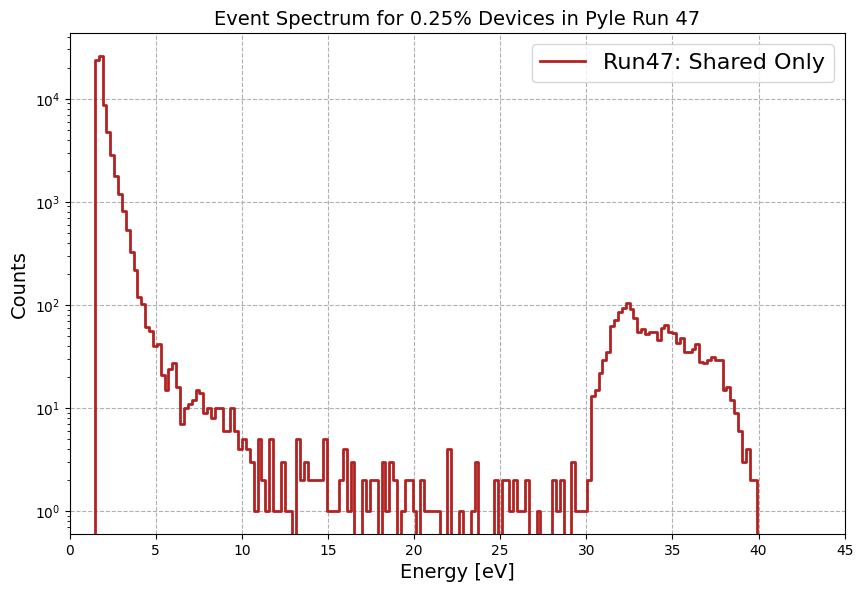

In [6]:
plt.step(sharededges[1:],sharedbins, where='mid',label='Run47: Shared Only',linewidth=2,color='firebrick') #plot the hist and fit together 
plt.yscale('log')
#plt.ylim(1e-4,1e0)
plt.xlim(0,45)
plt.title(f'Event Spectrum for 0.25% Devices in Pyle Run 47',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
plt.xlabel('Energy [eV]',fontsize = 14)
#plt.vlines(2200,ymin=0,ymax=10e5,colors='r', label='cut')
plt.grid(linestyle="dashed")
plt.legend(fontsize = 16)

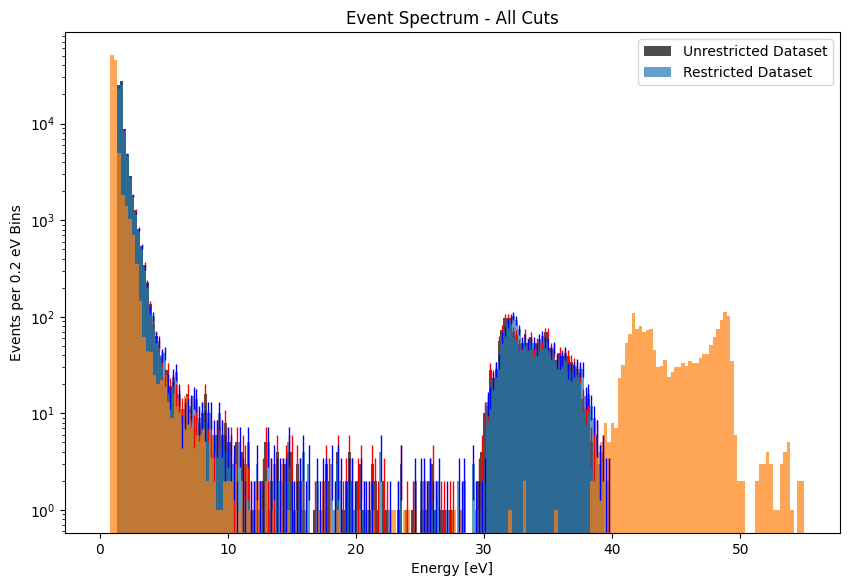

In [7]:
mpl.rcParams['figure.figsize'] = [10, 6.5]
olderrors = np.sqrt(sharedbinsold)
newerrors = np.sqrt(sharedbins)
plt.bar(sharedbin_centers_old, sharedbinsold,yerr = olderrors, width=(sharededgesold[1] - sharededgesold[0]), edgecolor='none', alpha=0.7,label='Unrestricted Dataset',color='black',error_kw={'ecolor': 'red', 'elinewidth': 1})
plt.bar(sharedbin_centers, sharedbins,yerr = newerrors, width=(sharededges[1] - sharededges[0]), edgecolor='none', alpha=0.7,label='Restricted Dataset',error_kw={'ecolor': 'blue', 'elinewidth': 1})
plt.bar(run57bin_centers,run57bins, width=(run57edges[1] - run57edges[0]),edgecolor='none', alpha=0.7,)
plt.title('Event Spectrum - All Cuts')
plt.xlabel('Energy [eV]')
plt.ylabel('Events per 0.2 eV Bins')
plt.yscale('log')
plt.legend()
plt.show()

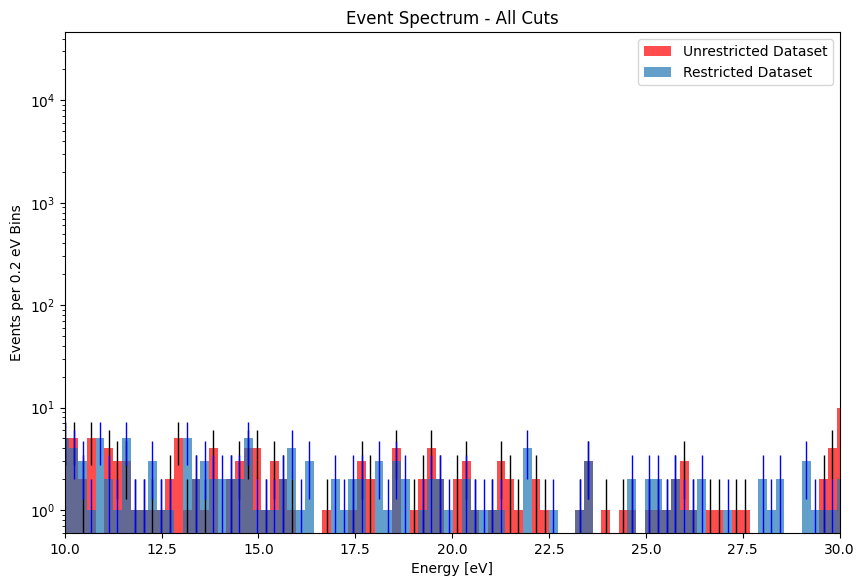

In [9]:
mpl.rcParams['figure.figsize'] = [10, 6.5]
olderrors = np.sqrt(sharedbinsold)
newerrors = np.sqrt(sharedbins)
plt.bar(sharedbin_centers_old, sharedbinsold,yerr = olderrors, width=(sharededgesold[1] - sharededgesold[0]), edgecolor='none', alpha=0.7,label='Unrestricted Dataset',color='red',error_kw={'ecolor': 'black', 'elinewidth': 1})
plt.bar(sharedbin_centers, sharedbins,yerr = newerrors, width=(sharededges[1] - sharededges[0]), edgecolor='none', alpha=0.7,label='Restricted Dataset',error_kw={'ecolor': 'blue', 'elinewidth': 1})

plt.xlim(10,30)
plt.title('Event Spectrum - All Cuts')
plt.xlabel('Energy [eV]')
plt.ylabel('Events per 0.2 eV Bins')
plt.yscale('log')
plt.legend()
plt.show()

/tmp/ipykernel_360841/3176909608.py:15: RuntimeWarning: invalid value encountered in divide
  chi2_values = (sharedbinsold - sharedbins) ** 2 / (errors1 ** 2 + errors2 ** 2)
/tmp/ipykernel_360841/3176909608.py:19: RuntimeWarning: invalid value encountered in divide
  residuals = (sharedbinsold - sharedbins) / np.sqrt(errors1 ** 2 + errors2 ** 2)


[           nan            nan            nan            nan
            nan            nan 4.61200759e+01 4.85115797e+01
 1.08372308e+00 2.38805970e-01 7.04473406e-04 9.70990237e-01
 2.95501022e+00 1.38632163e-01 1.12558140e-01 6.55274889e-01
 8.10810811e-02 8.89328063e-01 1.37634409e+00 3.22580645e-02
 2.33644860e-01 5.12820513e-02 4.90909091e+00 1.00000000e+00
 4.70588235e-01 2.00000000e-01 2.81395349e+00 1.33333333e-01
 8.88888889e-01 4.76190476e-02 9.25925926e-01 4.34782609e-02
 2.90909091e+00 1.08695652e+00 5.88235294e-02 0.00000000e+00
 2.66666667e+00 2.22222222e-01 1.00000000e+00 4.00000000e-01
 0.00000000e+00 5.29411765e-01 0.00000000e+00 1.33333333e+00
 0.00000000e+00 1.11111111e-01 2.00000000e-01 2.66666667e+00
 5.00000000e+00 6.66666667e-01 1.00000000e+00 5.00000000e-01
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 3.33333333e-01 5.00000000e+00 2.66666667e+00 0.00000000e+00
 1.00000000e+00 6.66666667e-01 2.00000000e+00 0.00000000e+00
 2.00000000e-01 1.111111

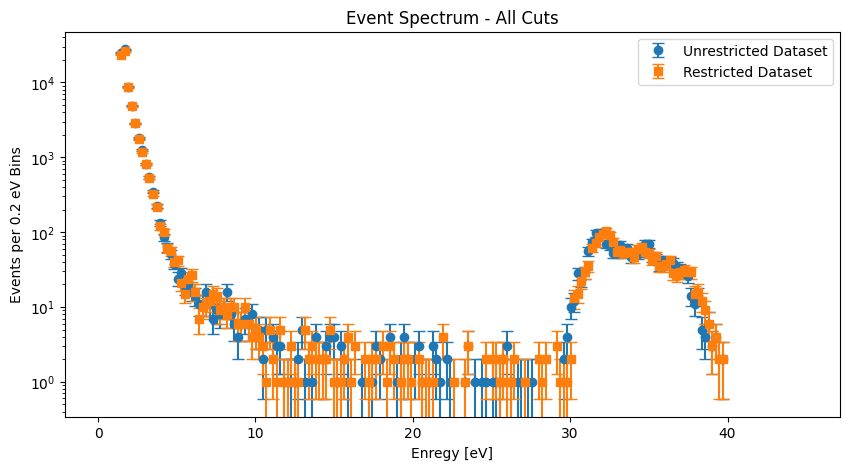

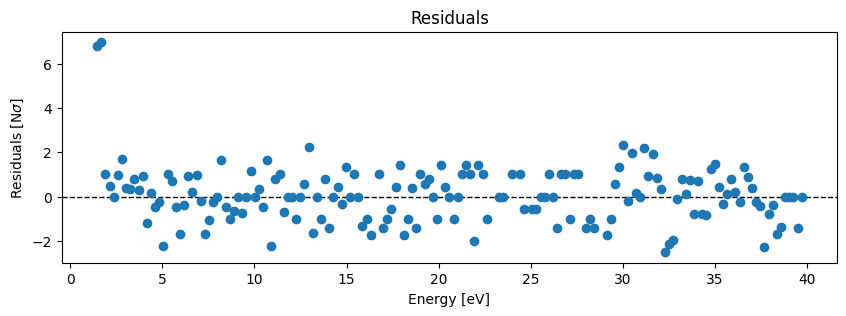

Chi-Squared Total: 268.27
0.0007670456263294545


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# Example histogram data
bins = np.linspace(0, 10, 11)  # Bin edges
#counts1 = np.array([10, 15, 20, 25, 30, 28, 18, 12, 8, 5])  # First histogram
#counts2 = np.array([9, 14, 22, 24, 31, 27, 17, 13, 7, 6])  # Second histogram

# Poisson errors (sqrt of counts)
errors1 = np.sqrt(sharedbinsold)
errors2 = np.sqrt(sharedbins)

# Compute Chi-Squared
chi2_values = (sharedbinsold - sharedbins) ** 2 / (errors1 ** 2 + errors2 ** 2)
chi2_total = np.nansum(chi2_values)
print(chi2_values)
# Compute Residuals
residuals = (sharedbinsold - sharedbins) / np.sqrt(errors1 ** 2 + errors2 ** 2)

# Plot histograms
plt.figure(figsize=(10, 5))
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.errorbar(sharedbin_centers_old, sharedbinsold, yerr=errors1, fmt='o', label='Unrestricted Dataset', capsize=4)
plt.errorbar(sharedbin_centers, sharedbins, yerr=errors2, fmt='s', label='Restricted Dataset', capsize=4)

plt.xlabel("Enregy [eV]")
plt.ylabel('Events per 0.2 eV Bins')
plt.legend()
plt.yscale('log')
plt.title("Event Spectrum - All Cuts")
plt.show()

# Plot residuals
plt.figure(figsize=(10, 3))
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.errorbar(sharedbin_centers, residuals, fmt='o', capsize=4)
plt.xlabel("Energy [eV]")
plt.ylabel(r"Residuals [N$\sigma$]")
plt.title("Residuals")
plt.show()


print(f"Chi-Squared Total: {chi2_total:.2f}")

from scipy.stats import chi2

p_value = 1 - chi2.cdf(chi2_total, 199)
print(p_value)


In [9]:
bigfinsshared_kev.min()

0.0015000046191921044

In [10]:
bigfinsshared_kev.max()

0.03972212801597882

In [11]:
energyrange_shared = np.arange(bigfinsshared_kev.min(), bigfinsshared_kev.max(),5e-4)
print(len(energyrange_shared))

77


In [8]:
energyrange_shared = np.arange(bigfinsshared_kev.min(), bigfinsshared_kev.max(),5e-4)
cutefficiency_shared = np.full(77,0.7954629629629629)#% cut efficiency
resolution_shared = 375e-6 #in units of kev. 
threshold_shared = 375e-6 * 4
exposure_r47 = 0.00012#for 23 hours minutes of data, and lets assume a cm^2 device is 0.24g. So that would be 0.375*0.24e-3 kgday


In [17]:
DMmasses = np.geomspace(0.01, 10, num=25)
extra_values = np.array([0.07, 0.068, 0.065, 0.063, 0.06, 0.058,0.053,0.05,0.045,0.042])
DMmasses = np.sort(np.concatenate((DMmasses, extra_values)))

In [18]:
sig_shared_5sig,ol1_shared_5sig,ol2_shared_5sig = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 35.
On mass 2 of 35.
On mass 3 of 35.
On mass 4 of 35.
On mass 5 of 35.
On mass 6 of 35.
On mass 7 of 35.
On mass 8 of 35.
On mass 9 of 35.
On mass 10 of 35.
On mass 11 of 35.
On mass 12 of 35.
On mass 13 of 35.
On mass 14 of 35.
On mass 15 of 35.
On mass 16 of 35.
On mass 17 of 35.
On mass 18 of 35.
On mass 19 of 35.
On mass 20 of 35.
On mass 21 of 35.
On mass 22 of 35.
On mass 23 of 35.
On mass 24 of 35.
On mass 25 of 35.
On mass 26 of 35.
On mass 27 of 35.
On mass 28 of 35.
On mass 29 of 35.
On mass 30 of 35.
On mass 31 of 35.
On mass 32 of 35.
On mass 33 of 35.
On mass 34 of 35.
On mass 35 of 35.


In [19]:
energyrange_run57 = np.arange(run57_kev.min(), run57_kev.max(),5e-4)
print(len(energyrange_run57))

108


In [20]:
energyrange_run57 = np.arange(run57_kev.min(), run57_kev.max(),5e-4)
cutefficiency_run57 = np.full(108,0.61)#% cut efficiency
resolution_run57 = 258e-6 #in units of kev. 
threshold_run57 = 258e-6 * 4
exposure_r57 = 0.00012#for 23 hours minutes of data, and lets assume a cm^2 device is 0.24g. So that would be 0.375*0.24e-3 kgday


In [21]:
sig_run57_4sig,ol1_run57_4sig,ol2_run57_4sig = darklim.limit.optimuminterval(run57_kev,energyrange_run57,cutefficiency_run57,DMmasses,exposure_r57,res=resolution_run57,verbose=True,hard_threshold=threshold_run57)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 35.
On mass 2 of 35.
On mass 3 of 35.
On mass 4 of 35.
On mass 5 of 35.
On mass 6 of 35.
On mass 7 of 35.
On mass 8 of 35.
On mass 9 of 35.
On mass 10 of 35.
On mass 11 of 35.
On mass 12 of 35.
On mass 13 of 35.
On mass 14 of 35.
On mass 15 of 35.
On mass 16 of 35.
On mass 17 of 35.
On mass 18 of 35.
On mass 19 of 35.
On mass 20 of 35.
On mass 21 of 35.
On mass 22 of 35.
On mass 23 of 35.
On mass 24 of 35.
On mass 25 of 35.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routine CnMax failed.
 Routin

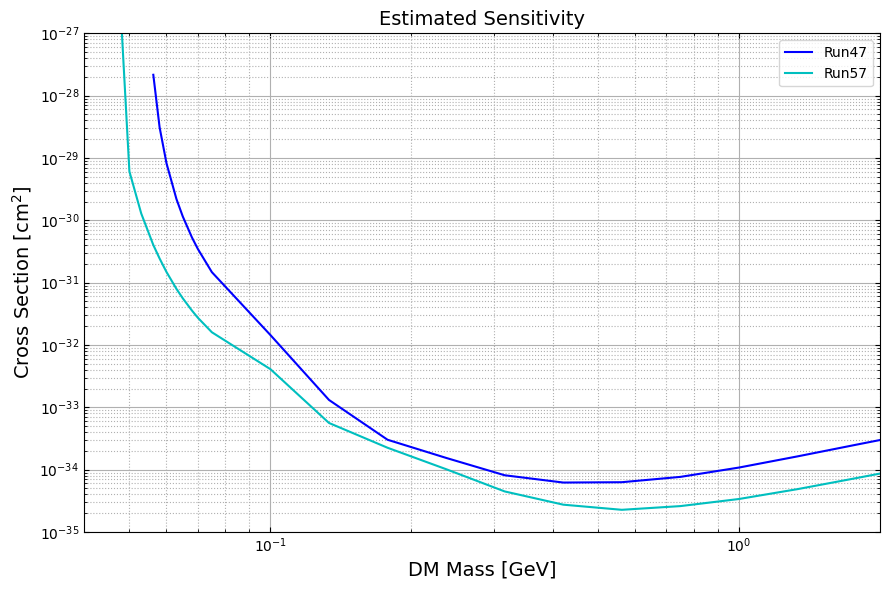

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig_shared_5sig, color='b',label="Run47")
ax.loglog(DMmasses, sig_run57_4sig, color='c',label="Run57")
ax.set_ylim(1e-35, 1e-27)
ax.set_xlim(0.04, 2)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

In [25]:
file_name = "run47_NRDM_limit_noboost_nodrde.txt"

# Save list to file
with open(file_name, "w") as file:
    for item,mass in zip(sig_shared_5sig,DMmasses):
        file.write(f"{mass}\t{item}\n")

file_name = "run57_NRDM_limit_noboost_nodrde.txt"

# Save list to file
with open(file_name, "w") as file:
    for item,mass in zip(sig_run57_4sig,DMmasses):
        file.write(f"{mass}\t{item}\n")

In [14]:
threshold_shared = 370e-6 * 4.5
sig_shared_4p5sig,ol1_shared_4p5sig,ol2_shared_4p5sig = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 8 of 31.
[0.00000000e+00 1.06599469e-13 2.13237539e-13 ... 9.63072150e-11
 9.63072150e-11 9.63072150e-11]
9.630721495781918e-11
20814.705078125
20814.705078125
On mass 9 of 31.
[0.00000000e+00 3.76517852e-12 7.53212398e-12 ... 3.63292813e-09
 3.63292813e-09 3.63292813e-09]
3.632928134724882e-09
20629.146484375
20629.146484375
On mass 10 of 31.
[0.00000000e+00 3.06220007e-11 6.12628150e-11 ... 3.27339335e-08
 3.27339335e-08 3.27339335e-08]
3.273393347301895e-08
20490.060546875
20490.060546875
On mass 11 of 31.
[0.00000000e+00 7.07721563e-11 1.41593701e-10 ... 8.10507057e-08
 8.10507057e-08 8.10507057e-08]
8.105070565851428e-08
20351.1640625
20351.1640625
On mass 12 of 3

In [15]:
threshold_shared = 370e-6 * 5.5
sig_shared_5p5sig,ol1_shared_5p5sig,ol2_shared_5p5sig = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 8 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 9 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 10 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 11 of 31.
[0.00000000e+00 7.59196091e-13 1.51871094e-12 ... 6.22074450e-10
 6.22074450e-10 6.22074450e-10]
6.22074449912303e-10
8825.4443359375
8825.4443359375
On mass 12 of 31.
[0.00000000e+00 1.34043519e-11 2.68169028e-11 ... 1.23034564e-08
 1.23034564e-08 1.23034564e-08]
1.2303456426516326e-08
8851.7734375
8851.7734375
On mass 13 of 31.
[0.00000000e+00 3.63695456e-11 7.27653689e-11 ... 3.60743517e-08
 3.60743517e-08 3.60743517e-08]
3.607435170581262e-08
8934.326171875
8934.326171875
On mass 14 of 31.
[0.00000000e+00 1.66010280e-10 3

In [16]:
threshold_shared = 370e-6 * 4.35
sig_shared_4p35sig,ol1_shared_4p35sig,ol2_shared_4p35sig = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 31.
[0.00000000e+00 4.11779864e-17 8.23691835e-17 ... 3.71182946e-14
 3.71182946e-14 3.71182946e-14]
3.7118294594313324e-14
24159.6484375
24159.6484375
On mass 8 of 31.
[0.00000000e+00 1.03561432e-12 2.07165735e-12 ... 9.87055527e-10
 9.87055527e-10 9.87055527e-10]
9.87055526940931e-10
23814.345703125
23814.345703125
On mass 9 of 31.
[0.00000000e+00 9.22476163e-12 1.84542610e-11 ... 9.38968276e-09
 9.38968276e-09 9.38968276e-09]
9.389682761761458e-09
23472.837890625
23472.837890625
On mass 10 of 31.
[0.00000000e+00 4.94639948e-11 9.89599550e-11 ... 5.57038921e-08
 5.57038921e-08 5.57038921e-08]
5.5703892108892874e-08
23001.171875
23001.171875
On mass 11 of 31.
[0.00000000e+00 1.02277411e-10 2.04628617e-10 ..

In [17]:
threshold_shared = 370e-6 * 4
sig_shared_4sig,ol1_shared_4sig,ol2_shared_4sig = darklim.limit.optimuminterval(bigfinsshared_kev,energyrange_shared,cutefficiency_shared,DMmasses,exposure_r47,res=resolution_shared,verbose=True,hard_threshold=threshold_shared)
#sig_all,ol1_all,ol2_all = darklim.limit.optimuminterval(bigfinsall_kev,energyrange_all,cutefficiency_all,DMmasses,exposure_r47,res=resolution_all,verbose=True,hard_threshold=threshold_all)

On mass 1 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 2 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 3 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 4 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 5 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 6 of 31.
[0. 0. 0. ... 0. 0. 0.]
0.0
On mass 7 of 31.
[0.00000000e+00 7.51136650e-13 2.25397206e-12 ... 1.50785173e-09
 1.50785173e-09 1.50785173e-09]
1.5078517254734396e-09
32419.689453125
32419.689453125
On mass 8 of 31.
[0.00000000e+00 4.84468404e-12 1.45380688e-11 ... 1.02837513e-08
 1.02837513e-08 1.02837513e-08]
1.0283751328761616e-08
31620.779296875
31620.779296875
On mass 9 of 31.
[0.00000000e+00 1.67315223e-11 5.02098469e-11 ... 3.78819607e-08
 3.78819607e-08 3.78819607e-08]
3.788196071550578e-08
30779.939453125
30779.939453125
On mass 10 of 31.
[0.00000000e+00 5.51102881e-11 1.65387199e-10 ... 1.37485327e-07
 1.37485327e-07 1.37485327e-07]
1.3748532730115016e-07
29652.9296875
29652.9296875
On mass 11 of 31.
[0.00000000e+00 9.73032890e-11 2.9201523

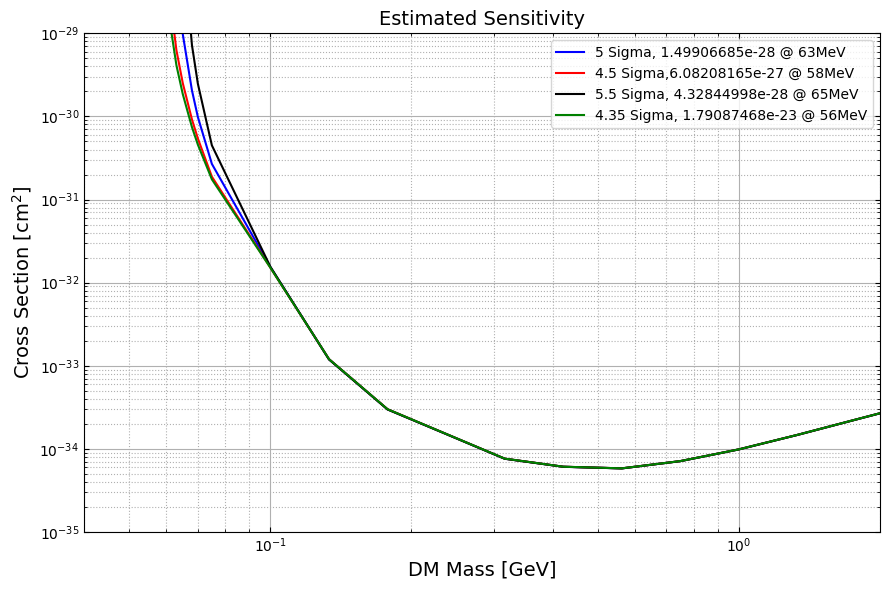

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig_shared_5sig, color='b',label="5 Sigma, 1.49906685e-28 @ 63MeV")
ax.loglog(DMmasses, sig_shared_4p5sig, color='r',label="4.5 Sigma,6.08208165e-27 @ 58MeV")
ax.loglog(DMmasses, sig_shared_5p5sig, color='k',label="5.5 Sigma, 4.32844998e-28 @ 65MeV")
ax.loglog(DMmasses, sig_shared_4p35sig, color='g',label="4.35 Sigma, 1.79087468e-23 @ 56MeV")

ax.set_ylim(1e-35, 1e-29)
ax.set_xlim(0.04, 2)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

In [19]:
sig_shared_5sig

array([           inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf, 5.24907914e-29, 9.76840623e-30, 2.05470075e-30,
       9.85178363e-31, 2.68391489e-31, 1.53649235e-32, 1.19661920e-33,
       2.98877598e-34, 1.51029292e-34, 7.61807813e-35, 6.09407164e-35,
       5.82488325e-35, 7.12449064e-35, 9.86547763e-35, 1.47392844e-34,
       2.25657102e-34, 3.44600871e-34, 5.18718167e-34, 7.66551163e-34,
       1.11199689e-33, 1.58627537e-33, 2.23063400e-33])

In [20]:
sig_shared_5p5sig

array([           inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf, 1.41871191e-28, 7.19454203e-30,
       2.47664220e-30, 4.48919964e-31, 1.54941858e-32, 1.19126541e-33,
       2.97892720e-34, 1.50750476e-34, 7.60559228e-35, 6.08807030e-35,
       5.82014434e-35, 7.12057312e-35, 9.85927920e-35, 1.47307577e-34,
       2.25535502e-34, 3.44419763e-34, 5.18449438e-34, 7.66157214e-34,
       1.11142874e-33, 1.58546667e-33, 2.22949799e-33])

In [21]:
sig_shared_4p35sig

array([           inf,            inf,            inf,            inf,
                  inf,            inf, 6.50882502e-24, 2.41266525e-28,
       2.49985420e-29, 4.12918577e-30, 1.85403761e-30, 7.43256785e-31,
       4.57925916e-31, 1.75039188e-31, 1.50899440e-32, 1.20278813e-33,
       3.00057640e-34, 1.51395082e-34, 7.63459200e-35, 6.10210896e-35,
       5.83099247e-35, 7.12959521e-35, 9.87354404e-35, 1.47502875e-34,
       2.25813943e-34, 3.44834240e-34, 5.19064433e-34, 7.67058522e-34,
       1.11272965e-33, 1.58731667e-33, 2.23209518e-33])

In [22]:
sig_shared_4p5sig

array([           inf,            inf,            inf,            inf,
                  inf,            inf,            inf, 2.16128201e-27,
       5.67838001e-29, 6.25957787e-30, 2.51091757e-30, 9.18837998e-31,
       5.43136956e-31, 1.88380852e-31, 1.51540247e-32, 1.20133370e-33,
       2.99787050e-34, 1.51306537e-34, 7.63068029e-35, 6.10023624e-35,
       5.82958698e-35, 7.12841679e-35, 9.87167717e-35, 1.47477552e-34,
       2.25777896e-34, 3.44780600e-34, 5.18984807e-34, 7.66941788e-34,
       1.11256071e-33, 1.58707752e-33, 2.23175979e-33])

In [23]:
DMmasses

array([ 0.01      ,  0.01333521,  0.01778279,  0.02371374,  0.03162278,
        0.04216965,  0.05623413,  0.058     ,  0.06      ,  0.063     ,
        0.065     ,  0.068     ,  0.07      ,  0.07498942,  0.1       ,
        0.13335214,  0.17782794,  0.23713737,  0.31622777,  0.4216965 ,
        0.56234133,  0.74989421,  1.        ,  1.33352143,  1.77827941,
        2.37137371,  3.16227766,  4.21696503,  5.62341325,  7.49894209,
       10.        ])

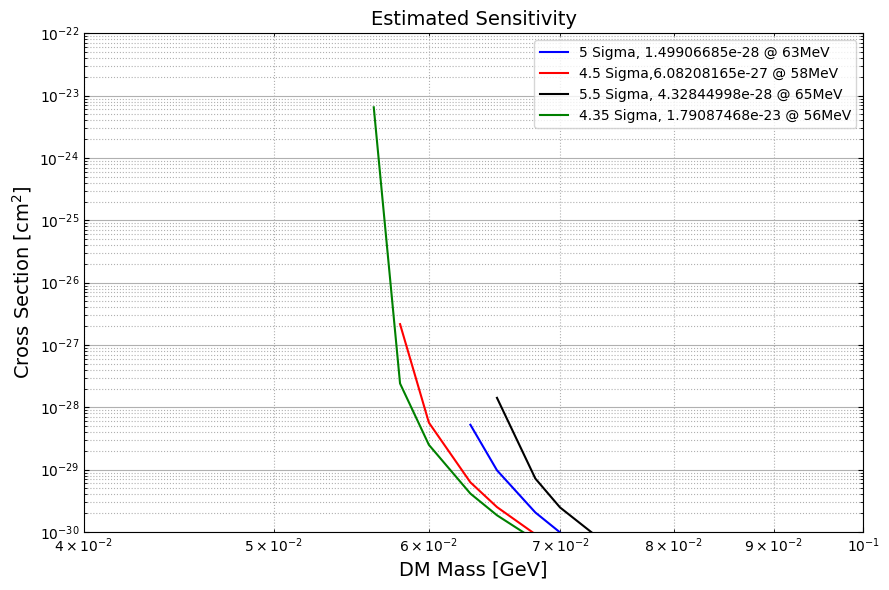

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, sig_shared_5sig, color='b',label="5 Sigma, 1.49906685e-28 @ 63MeV")
ax.loglog(DMmasses, sig_shared_4p5sig, color='r',label="4.5 Sigma,6.08208165e-27 @ 58MeV")
ax.loglog(DMmasses, sig_shared_5p5sig, color='k',label="5.5 Sigma, 4.32844998e-28 @ 65MeV")
ax.loglog(DMmasses, sig_shared_4p35sig, color='g',label="4.35 Sigma, 1.79087468e-23 @ 56MeV")

ax.set_ylim(1e-30, 1e-22)
ax.set_xlim(0.04, 0.1)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

Use full dRdE' spectrum

In [ ]:
"""
eff_stuff = np.loadtxt('/home/michael/run47analysis/pylelab_run47/diff_eff_interpolated_0p5eV_2sigBOOST_newsalt.txt')
eff_en = eff_stuff[0]
eff_grid = eff_stuff[1:]

eff_stuff_noboost = np.loadtxt('/home/michael/run47analysis/pylelab_run47/diff_eff_interpolated_0p5eV_2sigNOBOOST_oldsalt.txt')
eff_en_noboost = eff_stuff_noboost[0]
eff_grid_noboost = eff_stuff_noboost[1:]
"""

In [16]:
eff_stuff = np.loadtxt('/home/michael/run47analysis/pylelab_run47/diff_eff_interpolated_0p5eV_2sigBOOST_021825.txt')
eff_en = eff_stuff[0]
eff_grid = eff_stuff[1:]


In [17]:
def eff_smear_smooth_v2(x, f, eff):# all values are bin centers!!!
    binwidth = np.zeros(len(x))
    for i, x_center in enumerate(x) :
        x_low = x_center if i==0 else 0.5*(x_center+x[i-1])
        x_high = x_center if i==(len(x)-1) else 0.5*(x_center+x[i+1])
        binwidth[i] = x_high-x_low
    smearedRate = np.dot(f*binwidth,eff)#/binwidth
    abovePositive = False
    threshold = np.max(smearedRate)*0.99
    for i in range(len(smearedRate)-1):
        if (not abovePositive)&(smearedRate[i]>=threshold): 
            abovePositive = True
        if (smearedRate[i-1]<0)&(smearedRate[i]>=0)&abovePositive : 
            smearedRate[i:]=0
    smearedRate[smearedRate<=0] = 0
    return smearedRate

In [18]:
sigma0=1e-41
tm = 'Si'    
oi_sigma = []
oi_noboostsigma = []
threshold_shared = 375e-6 * 4
for m in DMmasses:
    init_rate = darklim.limit.drde(eff_en, m, sigma0, tm=tm)

    # Apply smearing, interpolate
    drde_detect_diff_0p5eV_smooth = eff_smear_smooth_v2(eff_en, init_rate, eff_grid)
    drdefunction_diff_0p5eV = interp1d( eff_en, drde_detect_diff_0p5eV_smooth, 
                                    kind="next", bounds_error=False, 
                                    fill_value=(0, drde_detect_diff_0p5eV_smooth[-1]) )  
    
    # Apply smearing, interpolate
    #drde_detect_diff_0p5eV_smooth_NOBOOST = eff_smear_smooth_v2(eff_en_noboost, init_rate, eff_grid_noboost)
    #drdefunction_diff_0p5eV_NOBOOST = interp1d( eff_en_noboost, drde_detect_diff_0p5eV_smooth_NOBOOST, 
                                   # kind="next", bounds_error=False, 
                                    #fill_value=(0, drde_detect_diff_0p5eV_smooth_NOBOOST[-1]) )  

    # Calculate OI limit without overburden
    sigma_diff_0p5eV,oistart,oiend = darklim.limit.optimuminterval(bigfinsshared_kev, energyrange_shared, 
                        np.ones(len(energyrange_shared)), m, exposure_r47,
                        tm="Si", cl=0.9, res=None, gauss_width=None, verbose=False,
                        drdefunction=[drdefunction_diff_0p5eV], hard_threshold=threshold_shared)
    
    # Calculate OI limit without overburden
    #sigma_diff_0p5eV_NOBOOST,oistartNOBOOST,oiendNOBOOST = darklim.limit.optimuminterval(bigfinsshared_kev, energyrange_shared, 
    #                    np.ones(len(energyrange_shared)), m, exposure_r47,
    #                    tm="Si", cl=0.9, res=None, gauss_width=None, verbose=False,
    #                    drdefunction=[drdefunction_diff_0p5eV_NOBOOST], hard_threshold=threshold_shared)

    oi_sigma.append(sigma_diff_0p5eV)
    #oi_noboostsigma.append(sigma_diff_0p5eV_NOBOOST)

[0. 0. 0. ... 0. 0. 0.]
0.0
[0. 0. 0. ... 0. 0. 0.]
0.0
[0. 0. 0. ... 0. 0. 0.]
0.0
[0.00000000e+00 7.45830853e-16 1.49190572e-15 ... 2.63539353e-13
 2.63539353e-13 2.63539353e-13]
2.635393532092928e-13
20667.91796875
20667.91796875
[0.00000000e+00 2.00593311e-11 4.01252250e-11 ... 8.51423664e-09
 8.51423664e-09 8.51423664e-09]
8.514236638333006e-09
25142.986328125
25142.986328125
[0.00000000e+00 3.05615373e-10 6.11330734e-10 ... 1.07850920e-07
 1.07850920e-07 1.07850920e-07]
1.0785092021011546e-07
35941.15625
35941.15625
[0.00000000e+00 2.33468787e-09 4.67013959e-09 ... 9.36184989e-07
 9.36184989e-07 9.36184989e-07]
9.361849886355399e-07
46446.48046875
46446.48046875
[0.00000000e+00 2.80599959e-09 5.61291723e-09 ... 1.17677534e-06
 1.17677534e-06 1.17677534e-06]
1.1767753417767274e-06
46463.9453125
46463.9453125
[0.00000000e+00 3.40176282e-09 6.80463859e-09 ... 1.50798455e-06
 1.50798455e-06 1.50798455e-06]
1.5079845508015562e-06
46139.13671875
46139.13671875
[0.00000000e+00 4.4078775

In [19]:
file_name = "run47_NRDM_limit_Final.txt"

# Save list to file
with open(file_name, "w") as file:
    for item,mass in zip(oi_sigma,DMmasses):
        file.write(f"{mass}\t{item}\n")

In [ ]:
"""
file_name = "run47_NRDM_limit_BOOST_newsalt.txt"

# Save list to file
with open(file_name, "w") as file:
    for item,mass in zip(oi_sigma,DMmasses):
        file.write(f"{mass}\t{item}\n")
        
file_name = "run47_NRDM_limit_NOBOOST_newsalt.txt"

# Save list to file
with open(file_name, "w") as file:
    for item,mass in zip(oi_noboostsigma,DMmasses):
        file.write(f"{mass}\t{item}\n")
"""

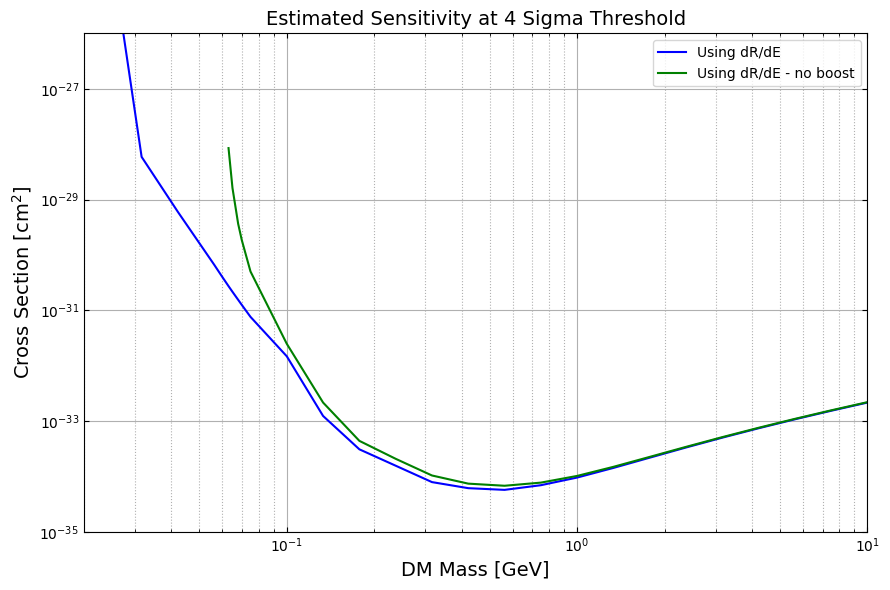

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(DMmasses, oi_sigma, color='b',label='Using dR/dE') 
ax.loglog(DMmasses, oi_noboostsigma, color='g',label='Using dR/dE - no boost')
#ax.loglog(DMmasses, sig_shared_4sig, color='r',label='Flat 0.80 Efficiency')

ax.set_ylim(1e-35, 1e-26)
ax.set_xlim(0.02, 10)
ax.set_xlabel("DM Mass [GeV]", fontsize=14)
ax.set_ylabel("Cross Section [cm$^2$]", fontsize=14)
ax.set_title("Estimated Sensitivity at 4 Sigma Threshold", fontsize=14)

ax.grid()
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend()

fig.tight_layout()

In [20]:
#x1tmig = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/XENON1T-Migdal.txt')

def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-1, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def load_and_plot_existing(ax, leg=True,lw=2,leg_params=None):
    curves_dir = 'ExistingLimits/'
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
    l1, = ax.plot(m_lim*1e3, x_lim, '--', color='#CFC0E5', lw=lw, label='CRESST-III 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_2020.txt').transpose()
    #l2, = ax.plot(m_lim*1e3, x_lim, linestyle = (0, (3, 1, 1, 1)), color='#C3B02F', lw=lw, label='DAMIC 2020')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Cosmic_Rays_2018.txt').transpose()
    #ax.plot(m_lim, x_lim, '--', color='#C9C0E5', lw=2, label='Cosmic Rays 2018')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'CDMSlite_2019.txt').transpose()
    #l3, = ax.plot(m_lim*1e3, x_lim, linestyle = (0, (3, 1, 1, 1, 1, 1)), color='#a4dbed', lw=lw, label='CDMSlite 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
    #l4, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENON1T Migdal 2019')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt').transpose()
    l5, = ax.plot( m_lim*1e3, x_lim, ':', color='#CE977A', lw=lw,label='CRESST-III 2023')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_Surface_2017.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='#C3B02F', lw=lw, label='nu-cleus 2017')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='darkgrey', lw=lw, label='PandaX-4T Migdal 2023') #color='#C3B02F'
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_2019.txt').transpose()
    #l6, = ax.plot(m_lim, x_lim, '--', color='#56872C', lw=lw, label='XENON1T S2-Only 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'EDELWEISS_Migdal_2019.txt').transpose()
    #l7, = ax.plot(m_lim, x_lim, '--', color='#D7ADB7', lw=lw, label='EDELWEISS Migdal 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2022.txt').transpose()
    #l8, = ax.plot(m_lim, x_lim,marker = 'd', color='#bcced4', lw=lw, label='LZ 2022')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
    #l9, = ax.plot(m_lim, x_lim, '--', color='#a4bd8e', lw=lw, label='DarkSide-50 2023')
    
    if leg:
        leg1 = ax.legend(handles=[ l9, l1, l2, l3, 15, l4, l6, l7], **leg_params)
        ax.add_artist(leg1)
    
    return

In [21]:
def plotexcludedsi(ax, details=False, **kwargs):
    curves_dir = 'ExistingLimits/'
    xs2o = np.loadtxt(curves_dir + 'CDMSlite_2019.txt')
    xs2o[:, 0] *= 1e3
    #dsmig = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt')
    dsmig = np.loadtxt(curves_dir + 'CRESST_III_2019.txt')
    dsmig[:, 0] *= 1e3
    #lz22 = np.loadtxt(curves_dir + 'LZ_SI_2022.txt')
    pxmig = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt')
    pxmig[:, 0] *= 1e3
    data = minbound([pxmig,xs2o,dsmig], masses=None)#data.T[0])
    kwargs.setdefault('edgecolor', None)
    kwargs.setdefault('facecolor','#000000')
    kwargs.setdefault('alpha',0.05)
    #data = extrapolate(data, 1e5)
    ax.fill_between(*(data.T), 1e-26, **kwargs)#ax.get_ylim()[1]
    if details:
        load_and_plot_existing(ax,leg=False,lw=1)

/tmp/ipykernel_104002/1595376677.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


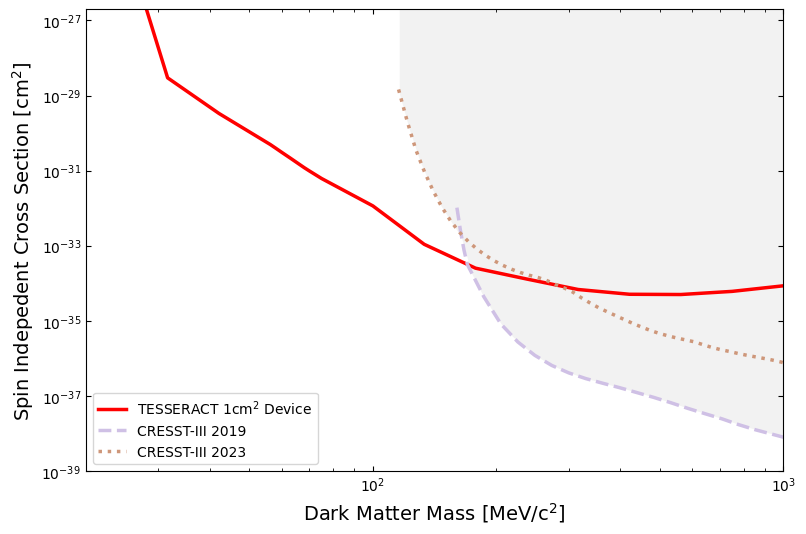

In [22]:
# money plot of sorts... selected run times 
#colors = cmap(np.linspace(0.5, 1, n_lines))

lss = ['--','-.','-']
    
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(DMmasses*1e3, oi_sigma, color='r',label=r"TESSERACT 1cm$^2$ Device",lw=2.5)
#ax.loglog(DMmasses, sig_all, color='g',label="All")
#ax.loglog(DMmasses, sig_big, color='r',label="Big fins -r46")
#ax.loglog(DMmasses, sig_reg, color='k',label="Reg fins -r46")
plotexcludedsi(ax, details=False)
load_and_plot_existing(ax,leg=False,lw=2.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-27)
ax.set_xlim(20, 1000)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='lower left')

In [24]:
def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))  
oldlims = np.genfromtxt(
    "/home/michael/DarkLim/examples/run47_NRDM_limit_021825.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

In [25]:
oldlims

array([[1.00000000e-02,            inf],
       [1.33352143e-02,            inf],
       [1.77827941e-02,            inf],
       [2.37137371e-02, 8.76334482e-25],
       [3.16227766e-02, 3.21199877e-29],
       [4.21696503e-02, 3.54579432e-30],
       [5.62341325e-02, 5.25698351e-31],
       [5.80000000e-02, 4.17973908e-31],
       [6.00000000e-02, 3.23324119e-31],
       [6.30000000e-02, 2.22913206e-31],
       [6.50000000e-02, 1.75803287e-31],
       [6.80000000e-02, 1.25626816e-31],
       [7.00000000e-02, 1.00141312e-31],
       [7.49894209e-02, 6.12218448e-32],
       [1.00000000e-01, 1.18904515e-32],
       [1.33352143e-01, 1.00110129e-33],
       [1.77827941e-01, 2.51469605e-34],
       [2.37137371e-01, 1.27369292e-34],
       [3.16227766e-01, 6.41802468e-35],
       [4.21696503e-01, 4.99918793e-35],
       [5.62341325e-01, 4.67140090e-35],
       [7.49894209e-01, 5.68708264e-35],
       [1.00000000e+00, 7.83301296e-35],
       [1.33352143e+00, 1.17015833e-34],
       [1.778279

/tmp/ipykernel_104002/1595376677.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


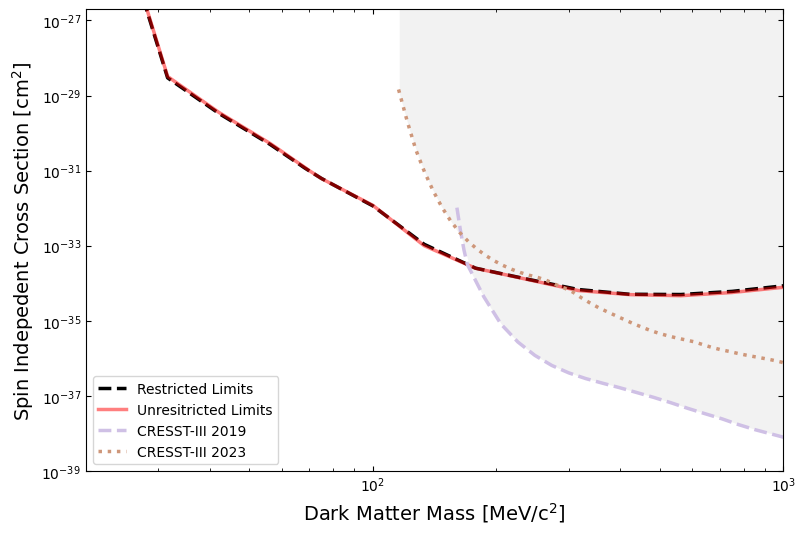

In [28]:
# money plot of sorts... selected run times 
#colors = cmap(np.linspace(0.5, 1, n_lines))

lss = ['--','-.','-']
    
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(DMmasses*1e3, oi_sigma, color='k',label=r"Restricted Limits",lw=2.5,linestyle='--')
ax.loglog(oldlims[:,0]*1e3, oldlims[:,1], color='r',label=r"Unresitricted Limits",lw=2.5,alpha=0.5)
#ax.loglog(DMmasses, sig_all, color='g',label="All")
#ax.loglog(DMmasses, sig_big, color='r',label="Big fins -r46")
#ax.loglog(DMmasses, sig_reg, color='k',label="Reg fins -r46")
plotexcludedsi(ax, details=False)
load_and_plot_existing(ax,leg=False,lw=2.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-27)
ax.set_xlim(20, 1000)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='lower left')

In [33]:
curves_dir = 'ExistingLimits/'
pxmig = np.loadtxt(curves_dir + 'CRESSTIII-Si-2022_cm.txt')
pxmig[:, 0] *= 1e3

In [34]:
pxmig

array([[1.15500000e+02, 1.44845397e-29],
       [1.21275000e+02, 2.03336190e-30],
       [1.27338750e+02, 3.50769561e-31],
       [1.33705688e+02, 9.03332993e-32],
       [1.40390972e+02, 2.81508774e-32],
       [1.47410520e+02, 1.04236479e-32],
       [1.54781046e+02, 4.52308886e-33],
       [1.62520099e+02, 2.28714482e-33],
       [1.70646104e+02, 1.30779795e-33],
       [1.79178409e+02, 8.19518547e-34],
       [1.88137329e+02, 5.53015873e-34],
       [1.97544196e+02, 3.96716704e-34],
       [2.07421406e+02, 2.99479106e-34],
       [2.17792476e+02, 2.36160233e-34],
       [2.28682100e+02, 1.93522810e-34],
       [2.40116205e+02, 1.64043057e-34],
       [2.52122015e+02, 1.43273632e-34],
       [2.64728116e+02, 1.19759076e-34],
       [2.77964521e+02, 9.39750416e-35],
       [2.91862748e+02, 7.55679655e-35],
       [3.06455885e+02, 5.88753810e-35],
       [3.21778679e+02, 4.13235259e-35],
       [3.37867613e+02, 3.00156221e-35],
       [3.54760994e+02, 2.23702237e-35],
       [3.724990

In [35]:
DMmasses

array([ 0.01      ,  0.01333521,  0.01778279,  0.02371374,  0.03162278,
        0.04216965,  0.05623413,  0.058     ,  0.06      ,  0.063     ,
        0.065     ,  0.068     ,  0.07      ,  0.07498942,  0.1       ,
        0.13335214,  0.17782794,  0.23713737,  0.31622777,  0.4216965 ,
        0.56234133,  0.74989421,  1.        ,  1.33352143,  1.77827941,
        2.37137371,  3.16227766,  4.21696503,  5.62341325,  7.49894209,
       10.        ])

In [36]:
curves_dir = 'ExistingLimits/'
dsmig = np.loadtxt(curves_dir + 'CRESST_III_2019.txt')
dsmig[:, 0] *= 1e3

In [37]:
dsmig

array([[1.60200e+02, 1.03290e-32],
       [1.63400e+02, 2.55305e-33],
       [1.66700e+02, 7.65682e-34],
       [1.69400e+02, 3.58724e-34],
       [1.70000e+02, 3.12301e-34],
       [1.86300e+02, 4.38576e-35],
       [2.05000e+02, 8.27109e-36],
       [2.25500e+02, 2.73740e-36],
       [2.48000e+02, 1.20626e-36],
       [2.72800e+02, 6.48955e-37],
       [3.00100e+02, 4.11481e-37],
       [3.30100e+02, 2.89870e-37],
       [3.63100e+02, 2.17980e-37],
       [3.99400e+02, 1.65712e-37],
       [4.39400e+02, 1.23296e-37],
       [4.83300e+02, 9.15361e-38],
       [5.31600e+02, 6.61865e-38],
       [5.84800e+02, 4.68175e-38],
       [6.43300e+02, 3.38750e-38],
       [7.07600e+02, 2.47281e-38],
       [7.78400e+02, 1.72011e-38],
       [8.56200e+02, 1.25105e-38],
       [9.41800e+02, 9.50135e-39],
       [1.03600e+03, 7.20338e-39],
       [1.13960e+03, 5.70352e-39],
       [1.25360e+03, 4.58772e-39],
       [1.37900e+03, 3.59982e-39],
       [1.51690e+03, 2.77873e-39],
       [1.66850e+03,